In [1]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import seaborn as sns
import geopandas as gpd

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

sys.path.append(os.path.abspath("../.."))
from function import ART_downscale as ART_down
from function import ART_statistic as ART_stat

import warnings
warnings.filterwarnings('ignore')

In [2]:
veneto_dir = os.path.join('/','media','arturo','T9','Data','shapes','Europa','Italy')

In [3]:
if os.path.exists(veneto_dir):
    ITALY = gpd.read_file(os.path.join(veneto_dir,'Italy_clear.geojson'))
else:
    raise SystemExit(f"File not found: {veneto_dir}")

In [4]:
dir_in = os.path.join('..','..','output','RE',f'RE_IMERG.csv')
IMERG = pd.read_csv(dir_in)

In [5]:
dir_in = os.path.join('..','..','output','RE',f'RE_CMORPH.csv')
CMORPH = pd.read_csv(dir_in)

In [6]:
dir_in = os.path.join('..','..','output','RE',f'RE_MSWEP.csv')
MSWEP = pd.read_csv(dir_in)

In [7]:
dir_in = os.path.join('..','..','output','RE',f'RE_ERA5.csv')
ERA5 = pd.read_csv(dir_in)

In [8]:
dir_in = os.path.join('..','..','output','RE',f'RE_GSMaP.csv')
GSMaP = pd.read_csv(dir_in)

In [9]:
dir_in = os.path.join('..','..','output','RE',f'RE_CHIRPS.csv')
CHIRPS = pd.read_csv(dir_in)

In [10]:
dir_in = os.path.join('..','..','output','RE',f'RE_ENSEMBLE.csv')
ENSEMBLE = pd.read_csv(dir_in)

In [11]:
colors = ['royalblue','r', 'g', 'c', 'y', 'purple', 'orange', 'cyan']

Text(0.07, 0.85, '(g)')

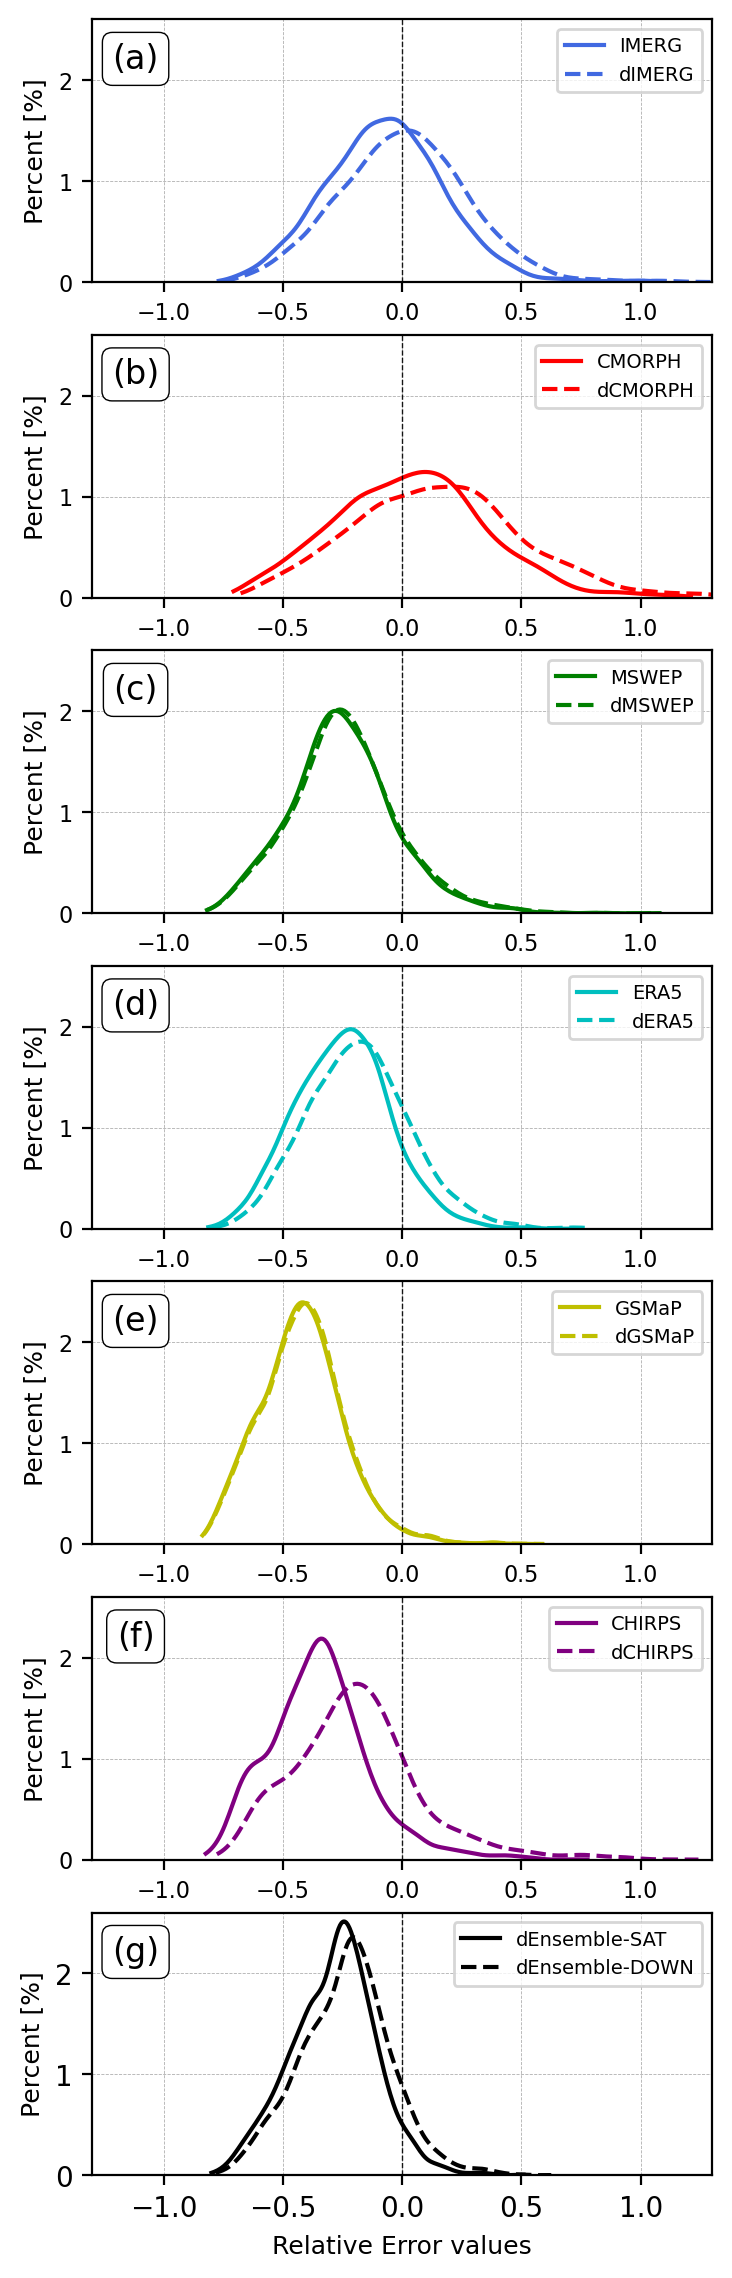

In [16]:
fig = plt.figure(figsize=(4,14),dpi=200)
gs = gridspec.GridSpec(7,1)

# =================================================================================
ax1 = plt.subplot(gs[0, 0])
sns.kdeplot(IMERG.RE_SAT,color=colors[0],cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'IMERG',
            clip=(np.nanmin(np.array(IMERG.RE_SAT)), np.nanmax(np.array(IMERG.RE_SAT))))
sns.kdeplot(IMERG.RE_DOWN,color=colors[0], linestyle='--',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'dIMERG',
            clip=(np.nanmin(np.array(IMERG.RE_DOWN)), np.nanmax(np.array(IMERG.RE_DOWN))))
ax1.axvline(0, color='k',linestyle='--',linewidth=0.5,alpha=0.9)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_xlim(-1.3,1.3)
ax1.set_ylim(0,2.6)
# ax1.set_xticklabels([])
ax1.set_xlabel('')
ax1.tick_params(axis='both', which='major', labelsize=8)
ax1.set_ylabel('Percent [%]',fontsize=9)
ax1.legend(fontsize=7, loc=0, ncol=1)

ax1.text(0.07, 0.85, '(a)', 
            fontsize=12, ha='center', va='center',
            transform=ax1.transAxes, zorder=20,
            bbox=dict(boxstyle="round,pad=0.3", 
                facecolor="white", 
                alpha=1,
                edgecolor="black",
                linewidth=0.5))


# =================================================================================
ax1 = plt.subplot(gs[1, 0])
sns.kdeplot(CMORPH.RE_SAT,color=colors[1],cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'CMORPH',
            clip=(np.nanmin(np.array(CMORPH.RE_SAT)), np.nanmax(np.array(CMORPH.RE_SAT))))
sns.kdeplot(CMORPH.RE_DOWN,color=colors[1], linestyle='--',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'dCMORPH',
            clip=(np.nanmin(np.array(CMORPH.RE_DOWN)), np.nanmax(np.array(CMORPH.RE_DOWN))))
ax1.axvline(0, color='k',linestyle='--',linewidth=0.5,alpha=0.9)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_xlim(-1.3,1.3)
ax1.set_ylim(0,2.6)
# ax1.set_xticklabels([])
ax1.set_xlabel('')
ax1.tick_params(axis='both', which='major', labelsize=8)
ax1.set_ylabel('Percent [%]',fontsize=9)
ax1.legend(fontsize=7, loc=0, ncol=1)

ax1.text(0.07, 0.85, '(b)', 
            fontsize=12, ha='center', va='center',
            transform=ax1.transAxes, zorder=20,
            bbox=dict(boxstyle="round,pad=0.3", 
                facecolor="white", 
                alpha=1,
                edgecolor="black",
                linewidth=0.5))

# =================================================================================
ax1 = plt.subplot(gs[2, 0])
sns.kdeplot(MSWEP.RE_SAT,color=colors[2],cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'MSWEP',
            clip=(np.nanmin(np.array(MSWEP.RE_SAT)), np.nanmax(np.array(MSWEP.RE_SAT))))
sns.kdeplot(MSWEP.RE_DOWN,color=colors[2], linestyle='--',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'dMSWEP',
            clip=(np.nanmin(np.array(MSWEP.RE_DOWN)), np.nanmax(np.array(MSWEP.RE_DOWN))))
ax1.axvline(0, color='k',linestyle='--',linewidth=0.5,alpha=0.9)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_xlim(-1.3,1.3)
ax1.set_ylim(0,2.6)
# ax1.set_xticklabels([])
ax1.set_xlabel('')
ax1.tick_params(axis='both', which='major', labelsize=8)
ax1.set_ylabel('Percent [%]',fontsize=9)
ax1.legend(fontsize=7, loc=0, ncol=1)

ax1.text(0.07, 0.85, '(c)', 
            fontsize=12, ha='center', va='center',
            transform=ax1.transAxes, zorder=20,
            bbox=dict(boxstyle="round,pad=0.3", 
                facecolor="white", 
                alpha=1,
                edgecolor="black",
                linewidth=0.5))

# =================================================================================
ax1 = plt.subplot(gs[3, 0])
sns.kdeplot(ERA5.RE_SAT,color=colors[3],cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'ERA5',
            clip=(np.nanmin(np.array(ERA5.RE_SAT)), np.nanmax(np.array(ERA5.RE_SAT))))
sns.kdeplot(ERA5.RE_DOWN,color=colors[3], linestyle='--',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'dERA5',
            clip=(np.nanmin(np.array(ERA5.RE_DOWN)), np.nanmax(np.array(ERA5.RE_DOWN))))
ax1.axvline(0, color='k',linestyle='--',linewidth=0.5,alpha=0.9)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_xlim(-1.3,1.3)
ax1.set_ylim(0,2.6)
# ax1.set_xticklabels([])
ax1.set_xlabel('')
ax1.tick_params(axis='both', which='major', labelsize=8)
ax1.set_ylabel('Percent [%]',fontsize=9)
ax1.legend(fontsize=7, loc=0, ncol=1)

ax1.text(0.07, 0.85, '(d)', 
            fontsize=12, ha='center', va='center',
            transform=ax1.transAxes, zorder=20,
            bbox=dict(boxstyle="round,pad=0.3", 
                facecolor="white", 
                alpha=1,
                edgecolor="black",
                linewidth=0.5))

# =================================================================================
ax1 = plt.subplot(gs[4, 0])
sns.kdeplot(GSMaP.RE_SAT,color=colors[4],cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'GSMaP',
            clip=(np.nanmin(np.array(GSMaP.RE_SAT)), np.nanmax(np.array(GSMaP.RE_SAT))))
sns.kdeplot(GSMaP.RE_DOWN,color=colors[4], linestyle='--',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'dGSMaP',
            clip=(np.nanmin(np.array(GSMaP.RE_DOWN)), np.nanmax(np.array(GSMaP.RE_DOWN))))
ax1.axvline(0, color='k',linestyle='--',linewidth=0.5,alpha=0.9)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_xlim(-1.3,1.3)
ax1.set_ylim(0,2.6)
# ax1.set_xticklabels([])
ax1.set_xlabel('')
ax1.tick_params(axis='both', which='major', labelsize=8)
ax1.set_ylabel('Percent [%]',fontsize=9)
ax1.legend(fontsize=7, loc=0, ncol=1)

ax1.text(0.07, 0.85, '(e)', 
            fontsize=12, ha='center', va='center',
            transform=ax1.transAxes, zorder=20,
            bbox=dict(boxstyle="round,pad=0.3", 
                facecolor="white", 
                alpha=1,
                edgecolor="black",
                linewidth=0.5))

# =================================================================================
ax1 = plt.subplot(gs[5, 0])
sns.kdeplot(CHIRPS.RE_SAT,color=colors[5],cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'CHIRPS',
            clip=(np.nanmin(np.array(CHIRPS.RE_SAT)), np.nanmax(np.array(CHIRPS.RE_SAT))))
sns.kdeplot(CHIRPS.RE_DOWN,color=colors[5], linestyle='--',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'dCHIRPS',
            clip=(np.nanmin(np.array(CHIRPS.RE_DOWN)), np.nanmax(np.array(CHIRPS.RE_DOWN))))
ax1.axvline(0, color='k',linestyle='--',linewidth=0.5,alpha=0.9)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_xlim(-1.3,1.3)
ax1.set_ylim(0,2.6)
# ax1.set_xticklabels([])
ax1.set_xlabel('')
ax1.tick_params(axis='both', which='major', labelsize=8)
ax1.set_ylabel('Percent [%]',fontsize=9)
ax1.legend(fontsize=7, loc=0, ncol=1)

ax1.text(0.07, 0.85, '(f)', 
            fontsize=12, ha='center', va='center',
            transform=ax1.transAxes, zorder=20,
            bbox=dict(boxstyle="round,pad=0.3", 
                facecolor="white", 
                alpha=1,
                edgecolor="black",
                linewidth=0.5))


# =================================================================================
ax1 = plt.subplot(gs[6, 0])
sns.kdeplot(ENSEMBLE.RE_SAT,color='k', linestyle='-',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'dEnsemble-SAT',
            clip=(np.nanmin(np.array(ENSEMBLE.RE_SAT)), np.nanmax(np.array(ENSEMBLE.RE_SAT))))
sns.kdeplot(ENSEMBLE.RE_DOWN,color='k', linestyle='--',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'dEnsemble-DOWN',
            clip=(np.nanmin(np.array(ENSEMBLE.RE_DOWN)), np.nanmax(np.array(ENSEMBLE.RE_DOWN))))
ax1.axvline(0, color='k',linestyle='--',linewidth=0.5,alpha=0.9)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_xlim(-1.3,1.3)
ax1.set_ylim(0,2.6)
ax1.set_ylabel('Percent [%]',fontsize=9)
ax1.set_xlabel('Relative Error values',fontsize=9)
ax1.legend(fontsize=7, loc=0, ncol=1)

ax1.text(0.07, 0.85, '(g)', 
            fontsize=12, ha='center', va='center',
            transform=ax1.transAxes, zorder=20,
            bbox=dict(boxstyle="round,pad=0.3", 
                facecolor="white", 
                alpha=1,
                edgecolor="black",
                linewidth=0.5))
